# **6주차 강화학습 실습**

안녕하세요.

Tobig's 24기 서민정, 정서윤입니다.

본 실습은 3x4 그리드 월드(GridWorld) 환경에서 에이전트가 함정을 피하고 목표 지점에 도달하는 최적의 경로를 학습하는 과정을 다룹니다.

환경의 완벽한 정보를 안다고 가정하는 동적 계획법(DP)부터, 경험을 통해 학습하는 몬테카를로(MC)와 시간차 학습(TD) 알고리즘까지 순차적으로 구현해봅니다. 이를 통해 각 강화학습 알고리즘의 작동 원리를 깊이 이해하고, 실질적인 차이점을 비교 분석해보겠습니다.

# **3x4 그리드 월드**

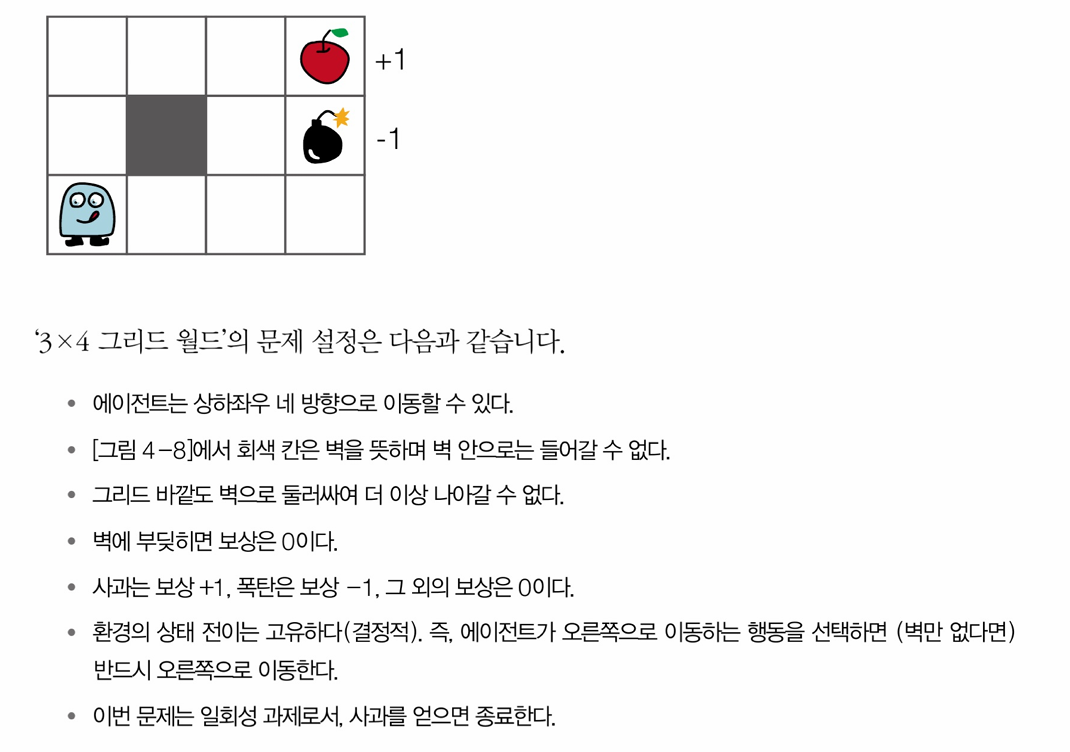

# **동적 프로그래밍(Dynamic Programming)**

동적 계획법은 환경의 전이 확률과 보상 함수를 모두 알고 있다는 가정 하에 동작합니다. 가치 반복(Value Iteration)은 벨만 최적 방정식을 업데이트 규칙으로 사용하여, 상태 가치 함수가 수렴할 때까지 반복 계산하여 최적 가치 함수와 최적 정책을 찾습니다.

**SETUP**

In [17]:
# install gridworld from pip
!pip install dezerogym

**1. 환경 초기화 및 무작위 가치 함수 시각화**

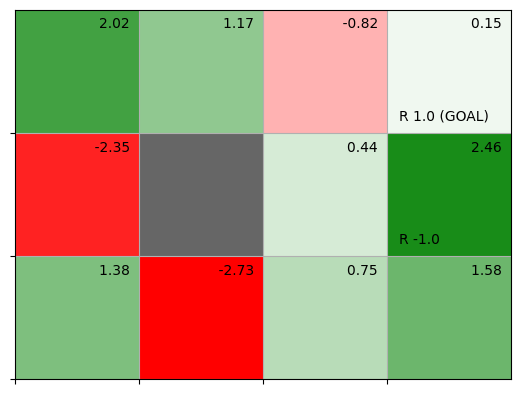

In [18]:
import numpy as np
from dezerogym.gridworld import GridWorld

env = GridWorld()
V = {}

for state in env.states():
    V[state] = np.random.randn()
env.render_v(V)

**2. 정책 평가 (Policy Evaluation)**

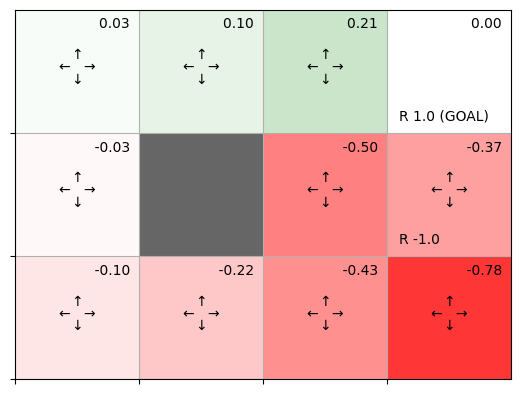

In [19]:
from collections import defaultdict
from dezerogym.gridworld import GridWorld


def eval_onestep(pi, V, env, gamma=0.9):
    for state in env.states():
        if state == env.goal_state:
            V[state] = 0
            continue

        action_probs = pi[state]
        new_V = 0
        for action, action_prob in action_probs.items():
            next_state = env.next_state(state, action)
            r = env.reward(state, action, next_state)
            new_V += action_prob * (r + gamma * V[next_state])
        V[state] = new_V
    return V


def policy_eval(pi, V, env, gamma, threshold=0.001):
    while True:
        old_V = V.copy()
        V = eval_onestep(pi, V, env, gamma)

        delta = 0
        for state in V.keys():
            t = abs(V[state] - old_V[state])
            if delta < t:
                delta = t

        if delta < threshold:
            break
    return V


env = GridWorld()
gamma = 0.9

pi = defaultdict(lambda: {0: 0.25, 1: 0.25, 2: 0.25, 3: 0.25})
V = defaultdict(lambda: 0)

V = policy_eval(pi, V, env, gamma)
env.render_v(V, pi)

**3. 정책 반복 (Policy Iteration)**

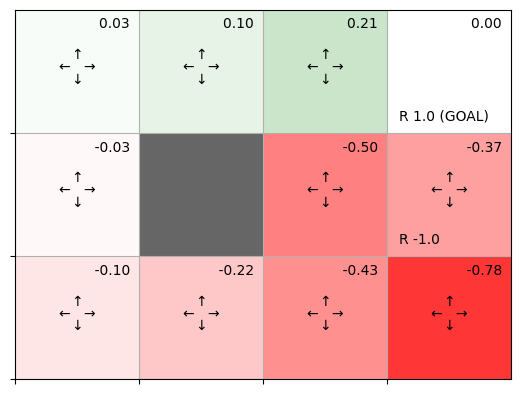

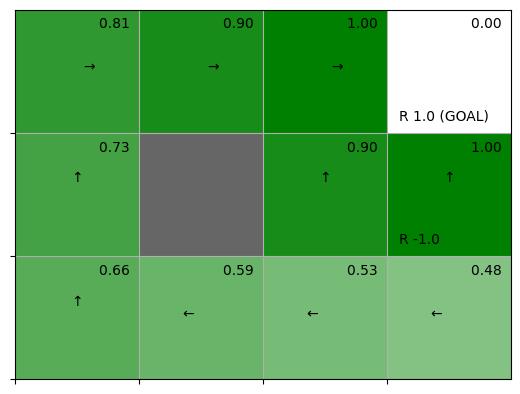

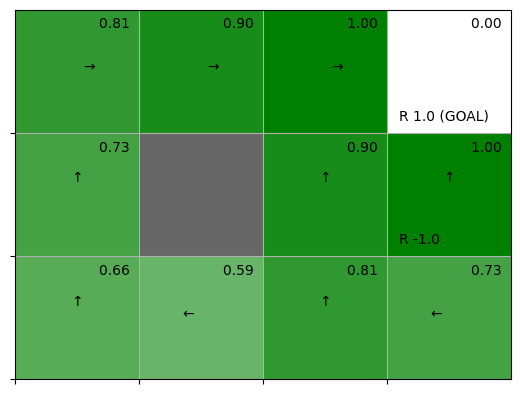

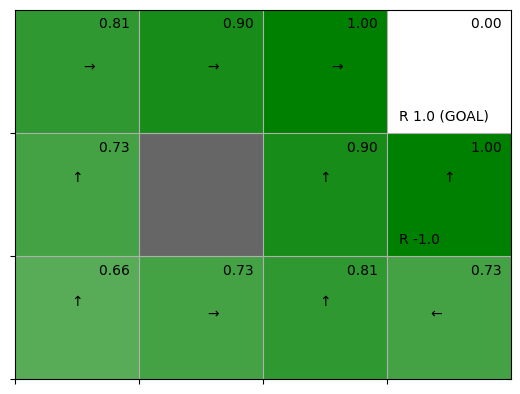

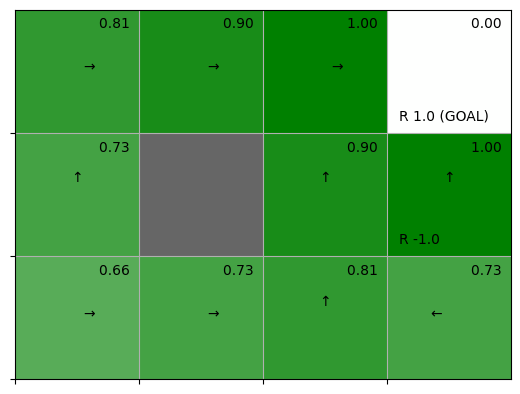

In [20]:
def argmax(d):
    """d (dict)"""
    max_value = max(d.values())
    max_key = -1
    for key, value in d.items():
        if value == max_value:
            max_key = key
    return max_key


def greedy_policy(V, env, gamma):
    pi = {}

    for state in env.states():
        action_values = {}

        for action in env.actions():
            next_state = env.next_state(state, action)
            r = env.reward(state, action, next_state)
            value = r + gamma * V[next_state]
            action_values[action] = value

        max_action = argmax(action_values)
        action_probs = {0: 0, 1: 0, 2: 0, 3: 0}
        action_probs[max_action] = 1.0
        pi[state] = action_probs
    return pi


def policy_iter(env, gamma, threshold=0.001, is_render=True):
    pi = defaultdict(lambda: {0: 0.25, 1: 0.25, 2: 0.25, 3: 0.25})
    V = defaultdict(lambda: 0)

    while True:
        V = policy_eval(pi, V, env, gamma, threshold)
        new_pi = greedy_policy(V, env, gamma)

        if is_render:
            env.render_v(V, pi)

        if new_pi == pi:
            break
        pi = new_pi

    return pi


env = GridWorld()
gamma = 0.9
pi = policy_iter(env, gamma)


**4. 가치 반복 (Value Iteration)**

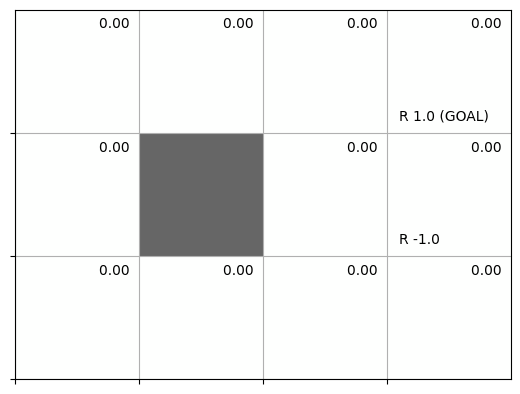

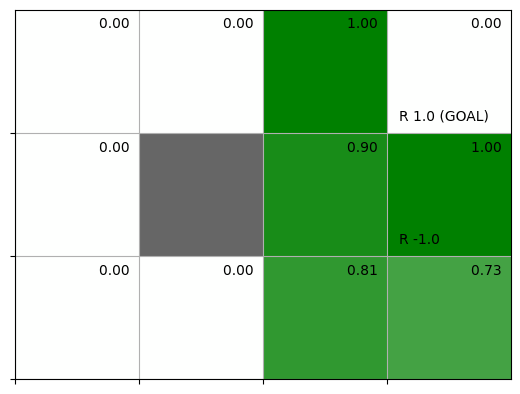

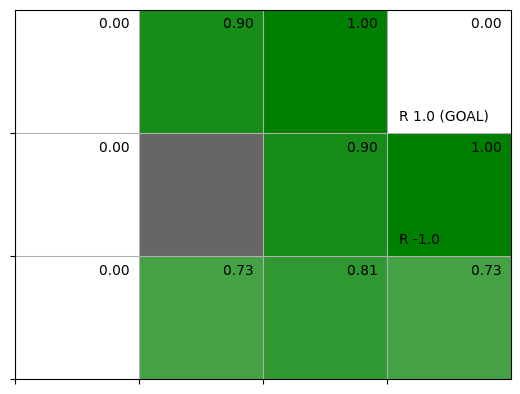

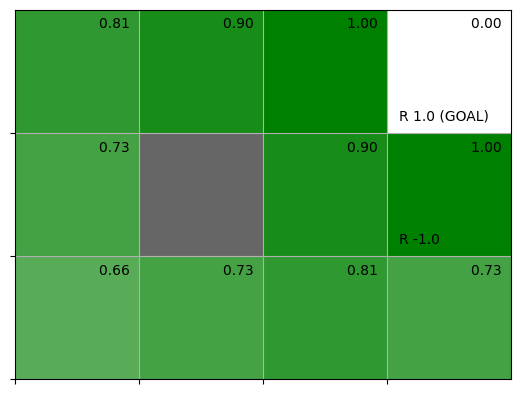

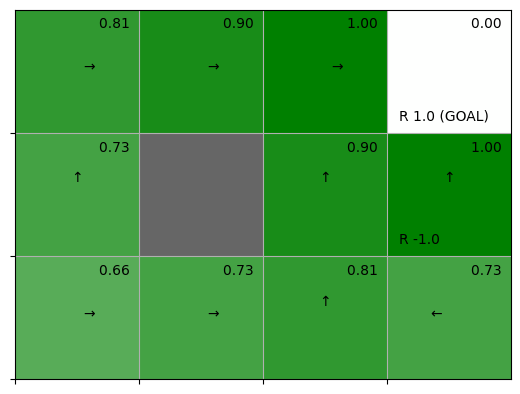

In [21]:
def value_iter_onestep(V, env, gamma):
    for state in env.states():
        if state == env.goal_state:
            V[state] = 0
            continue

        action_values = []
        for action in env.actions():
            next_state = env.next_state(state, action)
            r = env.reward(state, action, next_state)
            value = r + gamma * V[next_state]
            action_values.append(value)

        V[state] = max(action_values)
    return V


def value_iter(V, env, gamma, threshold=0.001, is_render=True):
    while True:
        if is_render:
            env.render_v(V)

        old_V = V.copy()
        V = value_iter_onestep(V, env, gamma)

        delta = 0
        for state in V.keys():
            t = abs(V[state] - old_V[state])
            if delta < t:
                delta = t

        if delta < threshold:
            break
    return V


V = defaultdict(lambda: 0)
env = GridWorld()
gamma = 0.9

V = value_iter(V, env, gamma)

pi = greedy_policy(V, env, gamma)
env.render_v(V, pi)

# **몬테카를로법(Monte Carlo Method)**

몬테카를로 방법은 환경의 모델을 모를 때, 에이전트가 직접 환경과 상호작용하며 얻은 에피소드(경험)를 바탕으로 학습합니다. 에피소드가 끝날 때까지 기다렸다가 실제 얻은 반환값을 사용하여 Q-함수를 업데이트합니다. 여기서 구현하는 비활성 정책(Off-policy) MC는 탐험을 위한 행동 정책(Behavior Policy)과 최적화하려는 목표 정책(Target Policy)을 분리하고 중요도 샘플링을 적용합니다.

**SETUP**

In [22]:
from collections import defaultdict
import numpy as np
from dezerogym.gridworld import GridWorld

**1. 무작위 에이전트를 이용한 MC 정책 평가**

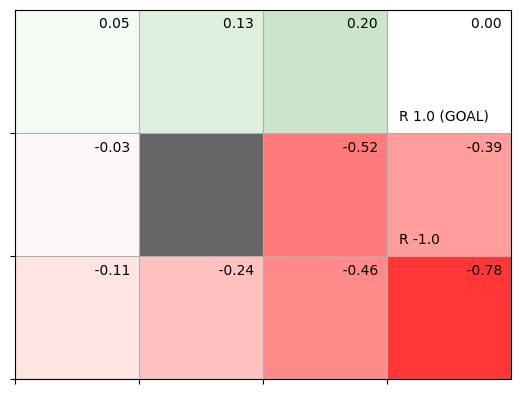

In [23]:
class RandomAgent:
    def __init__(self):
        self.gamma = 0.9
        self.action_size = 4

        random_actions = {0: 0.25, 1: 0.25, 2: 0.25, 3: 0.25}
        self.pi = defaultdict(lambda: random_actions)
        self.V = defaultdict(lambda: 0)
        self.cnts = defaultdict(lambda: 0)
        self.memory = []

    def get_action(self, state):
        action_probs = self.pi[state]
        actions = list(action_probs.keys())
        probs = list(action_probs.values())
        return np.random.choice(actions, p=probs)

    def add(self, state, action, reward):
        data = (state, action, reward)
        self.memory.append(data)

    def reset(self):
        self.memory.clear()

    def eval(self):
        G = 0
        for data in reversed(self.memory):  # 역방향으로(reserved) 따라가기
            state, action, reward = data
            G = self.gamma * G + reward
            self.cnts[state] += 1
            self.V[state] += (G - self.V[state]) / self.cnts[state]


env = GridWorld()
agent = RandomAgent()

episodes = 1000
for episode in range(episodes):  # 에피소드 1000번 수행
    state = env.reset()
    agent.reset()

    while True:
        action = agent.get_action(state)             # 행동 선택
        next_state, reward, done = env.step(action)  # 행동 수행

        agent.add(state, action, reward)  # (상태, 행동, 보상) 저장
        if done:   # 목표에 도달 시
            agent.eval()  # 몬테카를로법으로 가치 함수 갱신
            break         # 다음 에피소드 시작

        state = next_state

# 모든 에피소드 종료

# 가치 함수 시각화
env.render_v(agent.V)

**[공통 유틸리티] 엡실론-탐욕(epsilon-greedy) 확률 계산 함수**

In [24]:
def greedy_probs(Q, state, epsilon=0, action_size=4):
    qs = [Q[(state, action)] for action in range(action_size)]
    max_action = np.argmax(qs)

    base_prob = epsilon / action_size
    action_probs = {action: base_prob for action in range(action_size)}  #{0: ε/4, 1: ε/4, 2: ε/4, 3: ε/4}
    action_probs[max_action] += (1 - epsilon)
    return action_probs

**2. 활성 정책 MC 제어 (On-Policy MC Control)**

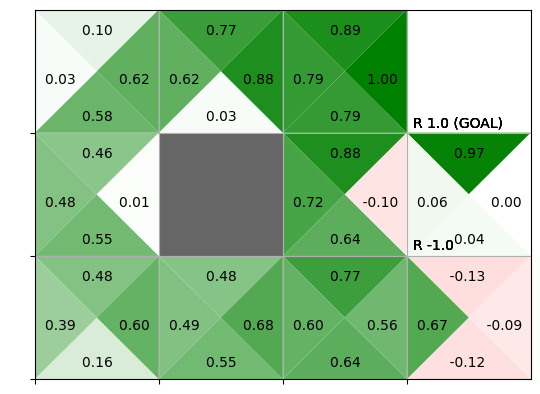

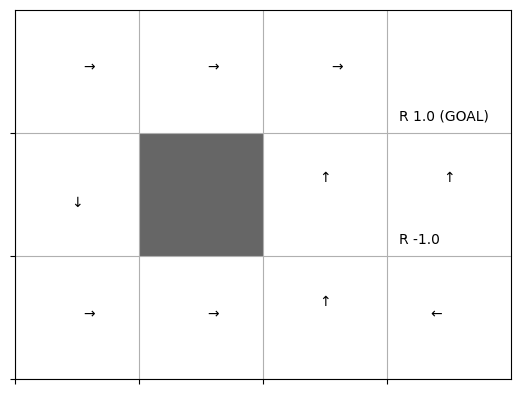

In [25]:
class McAgent:
    def __init__(self):
        self.gamma = 0.9
        self.epsilon = 0.1  # (첫 번째 개선) ε-탐욕 정책의 ε
        self.alpha = 0.1    # (두 번째 개선) Q 함수 갱신 시의 고정값 α
        self.action_size = 4

        random_actions = {0: 0.25, 1: 0.25, 2: 0.25, 3: 0.25}
        self.pi = defaultdict(lambda: random_actions)
        self.Q = defaultdict(lambda: 0)
        # self.cnts = defaultdict(lambda: 0)
        self.memory = []

    def get_action(self, state):
        action_probs = self.pi[state]
        actions = list(action_probs.keys())
        probs = list(action_probs.values())
        return np.random.choice(actions, p=probs)

    def add(self, state, action, reward):
        data = (state, action, reward)
        self.memory.append(data)

    def reset(self):
        self.memory.clear()

    def update(self):
        G = 0
        for data in reversed(self.memory):
            state, action, reward = data
            G = self.gamma * G + reward
            key = (state, action)
            # self.cnts[key] += 1
            # self.Q[key] += (G - self.Q[key]) / self.cnts[key]
            self.Q[key] += (G - self.Q[key]) * self.alpha
            self.pi[state] = greedy_probs(self.Q, state, self.epsilon)


env = GridWorld()
agent = McAgent()

episodes = 10000
for episode in range(episodes):
    state = env.reset()
    agent.reset()

    while True:
        action = agent.get_action(state)
        next_state, reward, done = env.step(action)

        agent.add(state, action, reward)
        if done:
            agent.update()
            break

        state = next_state

env.render_q(agent.Q)

**3. 비활성 정책 MC 제어 (Off-Policy MC Control)**

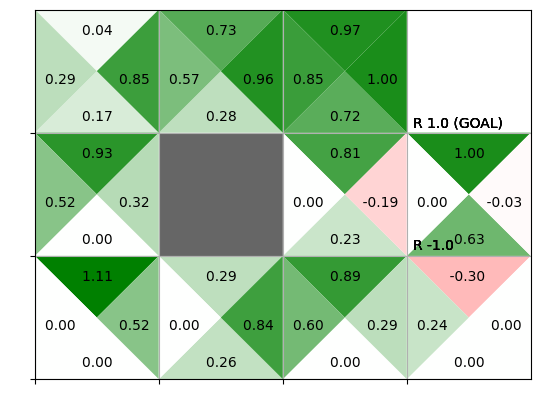

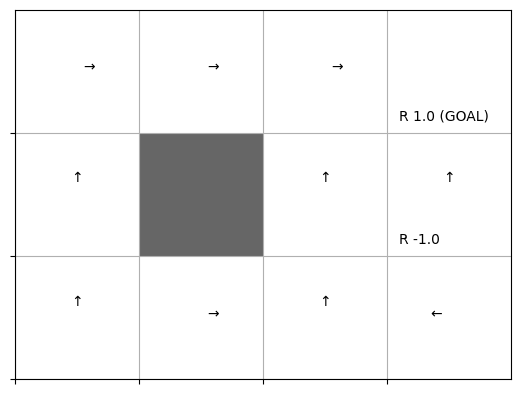

In [26]:
class McOffPolicyAgent:
    def __init__(self):
        self.gamma = 0.9
        self.epsilon = 0.1
        self.alpha = 0.2
        self.action_size = 4

        random_actions = {0: 0.25, 1: 0.25, 2: 0.25, 3: 0.25}
        self.pi = defaultdict(lambda: random_actions)
        self.b = defaultdict(lambda: random_actions)
        self.Q = defaultdict(lambda: 0)
        self.memory = []

    def get_action(self, state):
        action_probs = self.b[state]
        actions = list(action_probs.keys())
        probs = list(action_probs.values())
        return np.random.choice(actions, p=probs)

    def add(self, state, action, reward):
        data = (state, action, reward)
        self.memory.append(data)

    def reset(self):
        self.memory.clear()

    def update(self):
        G = 0
        rho = 1

        for data in reversed(self.memory):
            state, action, reward = data
            key = (state, action)

            G = self.gamma * rho * G + reward
            self.Q[key] += (G - self.Q[key]) * self.alpha
            rho *= self.pi[state][action] / self.b[state][action]

            self.pi[state] = greedy_probs(self.Q, state, epsilon=0)
            self.b[state] = greedy_probs(self.Q, state, self.epsilon)


env = GridWorld()
agent = McOffPolicyAgent()

episodes = 10000
for episode in range(episodes):
    state = env.reset()
    agent.reset()

    while True:
        action = agent.get_action(state)
        next_state, reward, done = env.step(action)

        agent.add(state, action, reward)
        if done:
            agent.update()
            break

        state = next_state

env.render_q(agent.Q)

# **TD법(Temporal Difference Methods)**

시간차(TD) 학습은 MC와 마찬가지로 모델 없이 학습하지만, 에피소드가 끝날 때까지 기다리지 않고 매 타임스텝마다 학습합니다. Q-Learning은 TD의 대표적인 비활성 정책 제어 알고리즘으로, 다음 상태에서 가능한 가장 큰 Q-값을 다음 타겟으로 사용하여 현재 상태의 Q-값을 실시간으로 업데이트합니다.

**[공통 유틸리티 함수]**

In [27]:
# utility functions (common functions)
def argmax(xs):
    idxes = [i for i, x in enumerate(xs) if x == max(xs)]
    if len(idxes) == 1:
        return idxes[0]
    elif len(idxes) == 0:
        return np.random.choice(len(xs))
    selected = np.random.choice(idxes)
    return selected

def greedy_probs(Q, state, epsilon=0, action_size=4):
    qs = [Q[(state, action)] for action in range(action_size)]
    max_action = argmax(qs)  # OR np.argmax(qs)
    base_prob = epsilon / action_size
    action_probs = {action: base_prob for action in range(action_size)}  #{0: ε/4, 1: ε/4, 2: ε/4, 3: ε/4}
    action_probs[max_action] += (1 - epsilon)
    return action_probs

**1. TD 정책 평가 (TD Evaluation)**

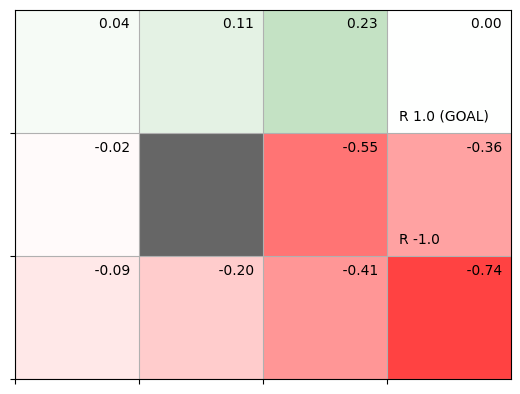

In [28]:
from collections import defaultdict
import numpy as np
from dezerogym.gridworld import GridWorld


class TdAgent:
    def __init__(self):
        self.gamma = 0.9
        self.alpha = 0.01
        self.action_size = 4

        random_actions = {0: 0.25, 1: 0.25, 2: 0.25, 3: 0.25}
        self.pi = defaultdict(lambda: random_actions)
        self.V = defaultdict(lambda: 0)

    def get_action(self, state):
        action_probs = self.pi[state]
        actions = list(action_probs.keys())
        probs = list(action_probs.values())
        return np.random.choice(actions, p=probs)

    def eval(self, state, reward, next_state, done):
        next_V = 0 if done else self.V[next_state]
        target = reward + self.gamma * next_V
        self.V[state] += (target - self.V[state]) * self.alpha


env = GridWorld()
agent = TdAgent()

episodes = 1000
for episode in range(episodes):
    state = env.reset()

    while True:
        action = agent.get_action(state)
        next_state, reward, done = env.step(action)

        agent.eval(state, reward, next_state, done)
        if done:
            break
        state = next_state

env.render_v(agent.V)

**2. SARSA (활성 정책 TD 제어, On-Policy TD Control)**

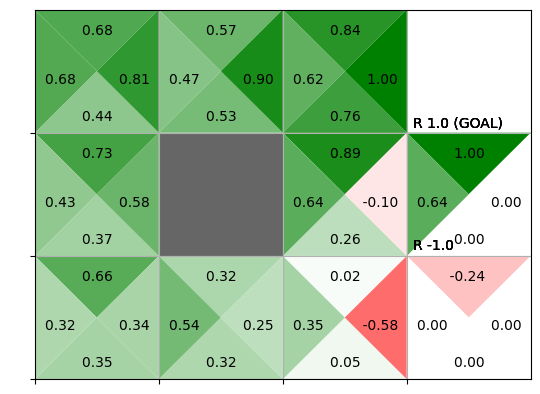

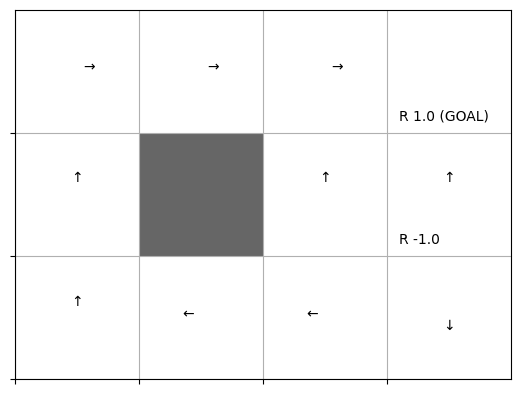

In [29]:
from collections import deque


class SarsaAgent:
    def __init__(self):
        self.gamma = 0.9
        self.alpha = 0.8
        self.epsilon = 0.1
        self.action_size = 4

        random_actions = {0: 0.25, 1: 0.25, 2: 0.25, 3: 0.25}
        self.pi = defaultdict(lambda: random_actions)
        self.Q = defaultdict(lambda: 0)
        self.memory = deque(maxlen=2)

    def get_action(self, state):
        action_probs = self.pi[state]
        actions = list(action_probs.keys())
        probs = list(action_probs.values())
        return np.random.choice(actions, p=probs)

    def reset(self):
        self.memory.clear()

    def update(self, state, action, reward, done):
        self.memory.append((state, action, reward, done))
        if len(self.memory) < 2:
            return

        state, action, reward, done = self.memory[0]
        next_state, next_action, _, _ = self.memory[1]
        next_q = 0 if done else self.Q[next_state, next_action]

        target = reward + self.gamma * next_q
        self.Q[state, action] += (target - self.Q[state, action]) * self.alpha
        self.pi[state] = greedy_probs(self.Q, state, self.epsilon)


env = GridWorld()
agent = SarsaAgent()

episodes = 10000
for episode in range(episodes):
    state = env.reset()
    agent.reset()

    while True:
        action = agent.get_action(state)
        next_state, reward, done = env.step(action)

        agent.update(state, action, reward, done)

        if done:
            agent.update(next_state, None, None, None)
            break
        state = next_state

env.render_q(agent.Q)

**3. 비활성 정책 SARSA (Off-Policy SARSA)**

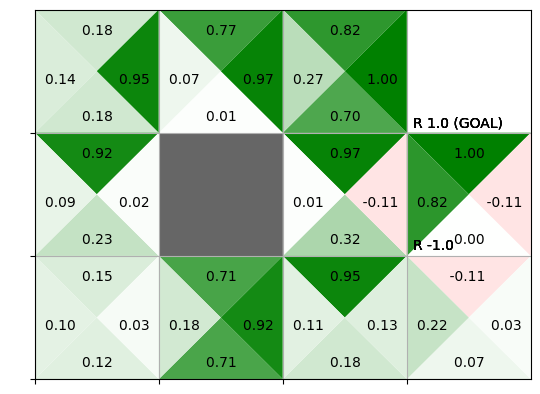

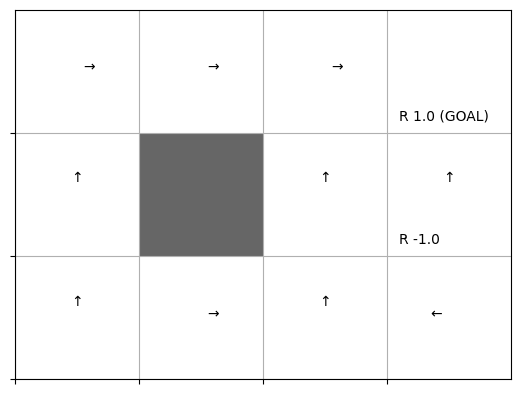

In [30]:
class SarsaOffPolicyAgent:
    def __init__(self):
        self.gamma = 0.9
        self.alpha = 0.8
        self.epsilon = 0.1
        self.action_size = 4

        random_actions = {0: 0.25, 1: 0.25, 2: 0.25, 3: 0.25}
        self.pi = defaultdict(lambda: random_actions)
        self.b = defaultdict(lambda: random_actions)
        self.Q = defaultdict(lambda: 0)
        self.memory = deque(maxlen=2)

    def get_action(self, state):
        action_probs = self.b[state]
        actions = list(action_probs.keys())
        probs = list(action_probs.values())
        return np.random.choice(actions, p=probs)

    def reset(self):
        self.memory.clear()

    def update(self, state, action, reward, done):
        self.memory.append((state, action, reward, done))
        if len(self.memory) < 2:
            return

        state, action, reward, done = self.memory[0]
        next_state, next_action, _, _ = self.memory[1]

        if done:
            next_q = 0
            rho = 1
        else:
            next_q = self.Q[next_state, next_action]
            rho = self.pi[next_state][next_action] / self.b[next_state][next_action]

        target = rho * (reward + self.gamma * next_q)
        self.Q[state, action] += (target - self.Q[state, action]) * self.alpha

        self.pi[state] = greedy_probs(self.Q, state, 0)
        self.b[state] = greedy_probs(self.Q, state, self.epsilon)


env = GridWorld()
agent = SarsaOffPolicyAgent()

episodes = 10000
for episode in range(episodes):
    state = env.reset()
    agent.reset()

    while True:
        action = agent.get_action(state)
        next_state, reward, done = env.step(action)

        agent.update(state, action, reward, done)

        if done:
            agent.update(next_state, None, None, None)
            break
        state = next_state

env.render_q(agent.Q)

**4. Q-Learning (버전 1: 목표 정책 pi와 행동 정책 b 명시적 분리)**

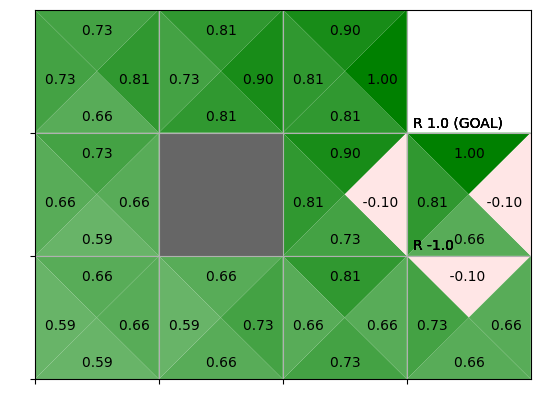

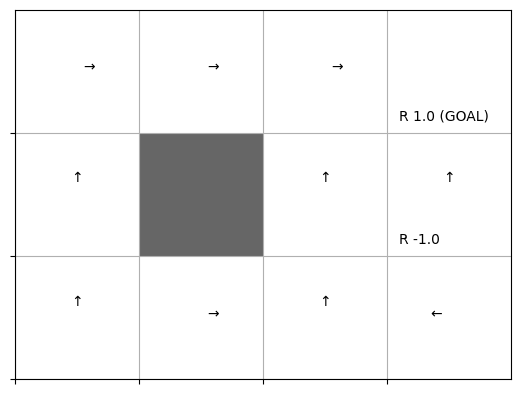

In [31]:
class QLearningAgent:
    def __init__(self):
        self.gamma = 0.9
        self.alpha = 0.8
        self.epsilon = 0.1
        self.action_size = 4

        random_actions = {0: 0.25, 1: 0.25, 2: 0.25, 3: 0.25}
        self.pi = defaultdict(lambda: random_actions)
        self.b = defaultdict(lambda: random_actions)
        self.Q = defaultdict(lambda: 0)

    def get_action(self, state):
        action_probs = self.b[state]
        actions = list(action_probs.keys())
        probs = list(action_probs.values())
        return np.random.choice(actions, p=probs)

    def update(self, state, action, reward, next_state, done):
        if done:
            next_q_max = 0
        else:
            next_qs = [self.Q[next_state, a] for a in range(self.action_size)]
            next_q_max = max(next_qs)

        target = reward + self.gamma * next_q_max
        self.Q[state, action] += (target - self.Q[state, action]) * self.alpha

        self.pi[state] = greedy_probs(self.Q, state, epsilon=0)
        self.b[state] = greedy_probs(self.Q, state, self.epsilon)


env = GridWorld()
agent = QLearningAgent()

episodes = 10000
for episode in range(episodes):
    state = env.reset()

    while True:
        action = agent.get_action(state)
        next_state, reward, done = env.step(action)

        agent.update(state, action, reward, next_state, done)
        if done:
            break
        state = next_state

env.render_q(agent.Q)

**5. Q-Learning (버전 2: 딕셔너리로 b와 pi를 유지하지 않고, get_action에서 즉석으로 엡실론-탐욕을 계산하여 메모리와 연산을 최적화)**

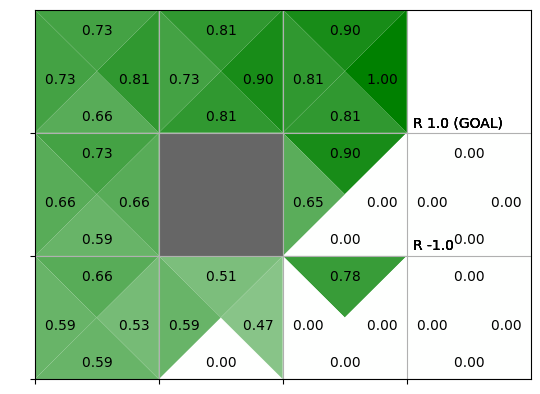

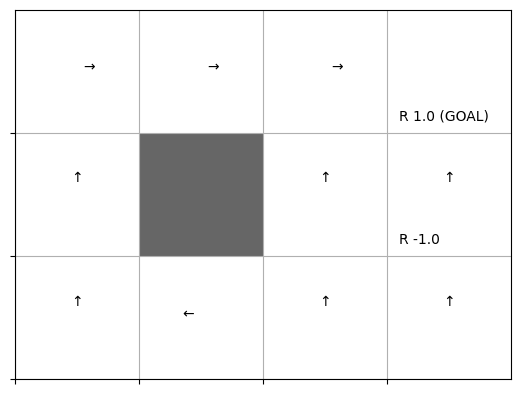

In [32]:
class QLearningAgent:
    def __init__(self):
        self.gamma = 0.9
        self.alpha = 0.8
        self.epsilon = 0.1
        self.action_size = 4
        self.Q = defaultdict(lambda: 0)

    def get_action(self, state):
        if np.random.rand() < self.epsilon:
            return np.random.choice(self.action_size)
        else:
            qs = [self.Q[state, a] for a in range(self.action_size)]
            return np.argmax(qs)

    def update(self, state, action, reward, next_state, done):
        if done:
            next_q_max = 0
        else:
            next_qs = [self.Q[next_state, a] for a in range(self.action_size)]
            next_q_max = max(next_qs)

        target = reward + self.gamma * next_q_max
        self.Q[state, action] += (target - self.Q[state, action]) * self.alpha


env = GridWorld()
agent = QLearningAgent()

episodes = 1000
for episode in range(episodes):
    state = env.reset()

    while True:
        action = agent.get_action(state)
        next_state, reward, done = env.step(action)

        agent.update(state, action, reward, next_state, done)
        if done:
            break
        state = next_state

env.render_q(agent.Q)

# **결과 분석 및 서술형 문제**

■ 과제 수행 방법:

DP, MC, TD의 모든 에이전트 코드를 순서대로 실행해보십시오. 각 학습이 완료된 후 출력되는 그리드월드 상의 가치(Value) 또는 Q-값(상태-행동 가치)과 에이전트의 정책 방향 화살표를 주의 깊게 관찰한 뒤, 아래의 질문에 대해 서술형으로 답안을 작성하여 제출 바랍니다.

**[문제 1]**

동적 계획법(DP)의 value_iter 코드와 시간차 학습(TD)의 QLearningAgent 코드를 비교해 보십시오.

DP는 에피소드를 진행하며 환경과 상호작용할 필요 없이 가치를 계산할 수 있었습니다. 그 이유(DP의 전제 조건)가 무엇인지 설명하고, 자율주행이나 주식 거래와 같은 현실 세계의 복잡한 문제에서 DP 대신 MC나 TD와 같은 모델 프리(Model-free) 알고리즘을 사용해야만 하는 이유를 서술하시오.

답안:

**DP가 환경과 상호작용 없이 가치를 계산할 수 있는 이유 (DP의 전제 조건)**

동적 계획법(Value Iteration / Policy Iteration)은 **환경의 완벽한 모델(model)을 이미 알고 있다는 것**을 전제로 한다. 구체적으로, 실습 코드의 `value_iter_onestep`을 보면 다음과 같이 동작한다.

```python
next_state = env.next_state(state, action)   
r = env.reward(state, action, next_state)    
value = r + gamma * V[next_state]
```

즉, 에이전트가 실제로 움직여 경험을 쌓지 않아도 **상태 전이 확률 P(s'|s,a)와 보상 함수 R(s,a,s')**가 함수 형태로 주어져 있기 때문에, 모든 상태 s를 순회하면서 벨만 최적 방정식 `V(s) = max_a [ R + γ V(s') ]`를 직접 한 번에 계산하여 수렴시킬 수 있다. 환경이 '결정적'이고 '유한하며' 'MDP가 완전히 알려져 있다'는 조건이 DP 성립의 핵심 가정이다.

반면 Q-Learning의 `update` 메서드는 환경에 대해 아무 것도 가정하지 않고, 오직 에이전트가 실제로 `env.step(action)`을 통해 받아낸 (state, action, reward, next_state) 샘플만으로 Q값을 갱신한다.

**현실 문제(자율주행·주식거래)에서 DP를 쓸 수 없는 이유**

1. **전이 확률과 보상을 모델링할 수 없다.** 자율주행에서 "이 속도·이 차로에서 핸들을 5도 꺾었을 때 0.1초 뒤 차량의 위치 분포 P(s'|s,a)"는 보행자, 노면 상태, 타차량 행동 등 수많은 요인에 의존하므로 명시적으로 쓸 수 없다. 주식도 마찬가지로 "현재 가격에서 매수 시 다음 시점 가격의 확률분포"를 사전에 알 수 없다.
2. **상태 공간이 거대하거나 연속이다.** DP는 모든 상태 s에 대해 매 반복마다 갱신하는 전수조사(sweep) 방식인데, 자율주행의 센서·위치·속도 조합이나 주식의 가격·포지션 벡터는 사실상 무한에 가까워 계산 불가능하다.
3. **환경이 비정상(non-stationary)이다.** 실제 시장이나 도로는 시간에 따라 규칙 자체가 변해, 마르코프 성질을 엄격히 만족하는 고정된 P, R이 존재한다고 보기 어렵다.

따라서 현실에서는 환경 모델을 쓰지 않고 **"직접 굴러보고 받은 샘플"만으로** 가치를 추정하는 MC·TD 같은 **모델 프리(model-free) 알고리즘**을 써야 한다. 이들은 `env.step()`이라는 '경험'만 있으면 학습이 가능하므로, 실세계 문제에 훨씬 범용적으로 적용된다.

**[문제 2]**

몬테카를로 제어(McAgent)와 시간차 제어(SarsaAgent) 코드를 보면 에이전트의 가치(self.Q)를 업데이트하는 시점(메서드 호출 시점)이 다릅니다.

1. 두 알고리즘이 각각 어느 시점에 가치를 업데이트하는지 코드를 바탕으로 설명하시오.

2. 이러한 업데이트 시점의 차이로 인해 발생하는 장단점(학습 속도, 편향과 분산 등)을 비교하여 서술하시오.

답안:

**1. 업데이트 시점의 차이**

- **McAgent (몬테카를로 제어)**: 메인 루프를 보면 `if done: agent.update()` 구조로, 에피소드가 **종료된 이후** `update`가 한 번 호출된다. `update` 내부에서는 `self.memory`에 쌓아둔 (state, action, reward) 전체 시퀀스를 **역방향으로 훑으며** 실제 반환값 `G = γ·G + reward`를 계산하고, 이 G로 `self.Q[key] += α (G − Q[key])`를 수행한다. 즉 **에피소드 단위 업데이트**다.

- **SarsaAgent (시간차 제어)**: 메인 루프에서 매 스텝마다 `agent.update(state, action, reward, done)`이 호출된다. deque(`maxlen=2`)에 직전 샘플과 현재 샘플 두 개가 쌓이는 순간, 곧바로 `target = reward + γ·Q[next_state, next_action]`을 만들고 `self.Q[state, action] += α (target − Q[state, action])`로 갱신한다. 즉 **매 타임스텝마다 즉시 업데이트(one-step bootstrapping)**한다.

**2. 장단점 비교**

- **학습 속도**
  - MC: 에피소드가 끝나야만 값이 갱신되므로 에피소드가 길거나 종료되지 않는 과제(continuing task)에는 사실상 쓸 수 없고, 한 번 갱신에 필요한 샘플 수가 많다 → **학습이 느리다**.
  - TD(SARSA): 매 스텝마다 Q가 바뀌고 그 값이 다음 스텝 타겟에 바로 재사용(bootstrapping)되므로 정보가 빠르게 전파된다 → **온라인 학습이 가능하고 일반적으로 더 빠르다**.

- **편향(bias)과 분산(variance)**
  - MC의 타겟은 실제 샘플링된 반환 G다. G는 `E[G|s] = V_π(s)`의 **불편 추정치**이므로 **편향은 0에 가깝다**. 그러나 에피소드 한 번 동안 수많은 확률적 전이·행동이 쌓여서 결정되기 때문에 **분산이 크다** → 값이 크게 흔들리며 수렴한다.
  - TD의 타겟은 `r + γ·Q[s', a']`로, 현재의 **추정치 Q**를 다시 사용한다(부트스트래핑). Q가 아직 부정확하면 타겟도 부정확해 **편향이 크다**. 반면 한 스텝의 확률성만 반영하므로 **분산은 작다**.

- **기타**
  - MC는 구현이 단순하고 오프라인 배치에 적합하며, 에피소드가 반드시 끝나야 한다는 제약이 있다.
  - TD는 non-terminating 과제에도 적용 가능하고, 함수근사와 결합 시 부트스트래핑으로 인해 불안정해질 수 있다는 단점이 있다(MC는 상대적으로 안정).

요약하면, **MC는 "정답(G)을 끝까지 기다려 보고 배운다 → 편향↓ 분산↑ 느림"**, **TD(SARSA)는 "일단 추정치로 바로 배운다 → 편향↑ 분산↓ 빠름"**이라는 전형적인 트레이드오프를 보인다.

**[문제 3]**

TD 학습 파트에서 SarsaAgent(활성 정책)와 QLearningAgent(비활성 정책)의 update 메서드 내부를 살펴보면, TD 타겟(Target)을 계산하는 방식에 핵심적인 차이가 있습니다.

1. SARSA는 타겟 계산을 위해 다음 상태의 어떤 값을 참조하며, Q-Learning은 어떤 값을 참조하는지 코드의 구체적인 변수명이나 로직을 들어 설명하시오.

2. 이 차이로 인해 그리드월드의 '함정' 근처에서 두 에이전트가 학습하는 최적 경로(안전 추구 vs. 최단 경로 추구)가 어떻게 달라질 수 있는지 추론하여 서술하시오.

답안:

**1. 타겟 계산 방식의 코드상 차이**

- **SARSA (on-policy)**: `update` 메서드에서
  ```python
  next_state, next_action, _, _ = self.memory[1]
  next_q = 0 if done else self.Q[next_state, next_action]
  target = reward + self.gamma * next_q
  ```
  처럼, 다음 상태에서 **에이전트가 자신의 정책 π(=ε-greedy)로 실제로 샘플링한 행동 `next_action`의 Q값** `Q[next_state, next_action]`을 그대로 타겟에 사용한다. 즉 "내가 실제로 할 다음 행동의 가치"를 참조한다.

- **Q-Learning (off-policy)**: `update` 메서드에서
  ```python
  next_qs = [self.Q[next_state, a] for a in range(self.action_size)]
  next_q_max = max(next_qs)
  target = reward + self.gamma * next_q_max
  ```
  처럼, 다음 상태에서의 **모든 가능한 행동 중 Q값이 가장 큰 것**(`max_a Q[next_state, a]`)을 타겟에 사용한다. 실제로 어떤 행동을 할지와 무관하게 "가장 좋은 행동을 한다고 가정했을 때의 가치"를 참조한다.

수식으로 쓰면:
- SARSA:       Q(s,a) ← Q(s,a) + α [ r + γ·Q(s', a') − Q(s,a) ],  a' ~ π (ε-greedy)
- Q-Learning:  Q(s,a) ← Q(s,a) + α [ r + γ·max_{a'} Q(s', a') − Q(s,a) ]

**2. 함정 근처에서 두 에이전트가 학습하는 경로의 차이**

그리드월드에서 함정(-1) 바로 옆을 따라가면 최단 경로이지만, 학습 중에는 ε의 확률로 무작위 행동이 나오므로 **함정으로 실수로 빠질 위험**이 있다.

- **SARSA는 "안전 추구"**: 타겟이 `Q(s', a')`이고 a'는 자신의 **행동 정책 그 자체**(탐험용 ε-greedy)로 뽑힌다. 따라서 함정 옆 칸에서 ε만큼의 확률로 함정에 빠지는 손실(-1)이 **Q값에 그대로 반영**된다. 결국 SARSA는 "나는 ε만큼 삐끗하는 놈이다"라는 사실을 가치에 포함시키므로, **함정에서 멀리 떨어진 안전한 우회 경로**를 최적 경로로 학습하는 경향이 있다. (Sutton & Barto의 Cliff Walking 예제에서 SARSA가 절벽에서 떨어진 경로를 택하는 이유.)

- **Q-Learning은 "최단 경로 추구"**: 타겟이 `max_a' Q(s', a')`, 즉 "다음 칸에서 **완벽하게 최적 행동을 한다는 가정** 하의" 가치를 쓴다. 탐험으로 인한 실수(함정에 빠지는 부분)는 업데이트 타겟에 전혀 반영되지 않는다. 따라서 학습된 Q는 **ε 노이즈가 없는 이상적 최적 정책의 가치**를 수렴시키고, 최종 정책은 **함정 바로 옆을 지나는 최단 경로**를 택한다. 대신 학습 중의 온라인 성능은 (ε 때문에 종종 함정에 빠져) SARSA보다 나쁠 수 있다.

정리하면, **SARSA는 "내가 탐험을 한다는 사실까지 감안한 안전한 정책"**, **Q-Learning은 "탐험과 무관하게 이론적으로 최적인 최단 정책"**을 학습한다.

**[문제 4]**

McOffPolicyAgent 및 SarsaOffPolicyAgent 코드를 보면, 직접 행동을 결정하는 정책(self.b)과 궁극적으로 최적화하려는 목표 정책(self.pi) 두 가지를 분리하여 운영합니다.

1. 왜 하나의 정책으로만 학습하지 않고 굳이 두 개의 정책을 분리해서 학습하는지 '탐험(Exploration)과 활용(Exploitation)의 딜레마' 관점에서 설명하시오.

2. 비활성 정책 코드에서 가치를 업데이트할 때 중요도 샘플링 비율인 rho($\rho$)를 곱해줍니다. 이 비율을 곱해주는 수학적/논리적 이유가 무엇인지 서술하시오.

답안:

**1. 왜 행동 정책 b와 목표 정책 π를 분리하는가 (Exploration vs Exploitation)**

강화학습 에이전트는 근본적으로 두 가지를 동시에 해야 한다.
- **활용(Exploitation)**: 지금까지 배운 바에 따라 가장 좋은(greedy) 행동을 해서 보상을 최대화하고 싶다.
- **탐험(Exploration)**: 아직 가보지 않은 상태/행동을 시도해서 Q값 추정의 정확도를 올리고, 더 나은 정책을 발견하고 싶다.

하나의 정책으로만 학습하면 이 두 가지가 충돌한다.
- 완전히 greedy한 π 하나만 쓰면 → 탐험 0 → 초기 Q가 잘못되어 있으면 **잘못된 경로에 빠져(local optimum) 영영 못 빠져나온다**.
- ε-greedy 하나만 쓰면(SARSA 계열) → 탐험은 되지만, 우리가 **실제로 수렴시키려는 대상이 '탐험까지 포함한 준최적 정책'**이 되어버려 진짜 최적 정책을 못 얻는다.

Off-policy는 이 딜레마를 **정책을 두 개로 분리**해서 해결한다.
- **행동 정책 b (behavior policy)**: 실제 환경과 상호작용할 때 쓰는 정책. 충분히 탐험적이어야 하므로 ε-greedy처럼 **확률적**으로 설계한다 → 탐험 담당.
- **목표 정책 π (target policy)**: 우리가 궁극적으로 학습·평가하고 싶은 정책. 보통 **완전 greedy(ε=0)**로 두어 "최적 정책"을 향해 수렴시킨다 → 활용 담당.

이렇게 분리하면, **데이터는 b로 넉넉히 탐험하며 수집**하고, 그 데이터를 이용해 **별개의 π(완전 greedy)의 가치**를 추정·개선할 수 있다. 즉 "탐험의 비용"과 "최적 정책의 학습"을 분리할 수 있다.

**2. 중요도 샘플링 비율 ρ를 곱해주는 수학적·논리적 이유**

우리가 궁극적으로 추정하고 싶은 값은 목표 정책 π 아래서의 기대 반환 `E_π[ G ]`이다. 하지만 에피소드의 (s, a) 궤적은 π가 아니라 **행동 정책 b로 샘플링**된 것이다. 즉, 기대하는 분포(π)와 실제 데이터가 뽑힌 분포(b)가 다르다.

이처럼 "분포 X 하의 기대값을 분포 Y에서 뽑은 샘플로 추정"하려면 **중요도 샘플링(Importance Sampling)**이 필요하다.

일반 공식:
  E_{x~π}[f(x)] = E_{x~b}[ (π(x)/b(x)) · f(x) ]

강화학습에 적용하면, 궤적 a_t, a_{t+1}, ... 의 동시 확률비
  ρ = Π_k  π(a_k | s_k) / b(a_k | s_k)
를 반환 G에 곱해야 **b에서 뽑은 샘플이 마치 π에서 뽑힌 것처럼 보정**된다. 즉
  E_π[G] = E_b[ ρ · G ].

실습의 `McOffPolicyAgent.update`에서
```python
G = self.gamma * rho * G + reward
rho *= self.pi[state][action] / self.b[state][action]
```
부분이 바로 이 계산이다. 역방향으로 훑으며 매 스텝마다 `π(a|s)/b(a|s)`를 곱해 나감으로써, 뒤쪽 궤적부터 순차적으로 확률비를 누적한다. 만약 **어떤 스텝에서 π(a|s)=0**(π가 선택하지 않을 행동)이라면 ρ=0이 되어 그 샘플은 업데이트에 기여하지 않는다 — 이는 "π가 절대 하지 않을 행동"에서 얻은 경험은 π의 가치 추정에 반영되면 안 되기 때문에 수학적으로도 옳다.

결론적으로 ρ는 **"b가 이 궤적을 만들 확률"과 "π가 이 궤적을 만들 확률"의 비**로, **샘플 분포의 차이를 보정하는 가중치**다. 이를 곱해야 비활성 정책 추정이 **불편(unbiased)**해진다.



**[문제 5]**

실습에 사용된 그리드월드의 보상 체계를 변경한다고 가정해 봅시다. 현재는 도착 지점에 도달하면 +1, 함정에 빠지면 -1의 보상을 받습니다.

만약 에이전트가 가능한 한 빨리 목적지에 도달하도록 유도하기 위해, 매 스텝 이동할 때마다 -0.01의 페널티 보상을 주도록 환경(Environment)을 변경한다면, 학습이 완료된 후의 최적 정책(화살표 방향)과 가치 함수는 기존과 비교하여 어떤 식으로 변할지 예상하여 논리적으로 서술하시오.

답안:

**변경된 보상 체계**
- 기존: 목표 +1, 함정 −1, 나머지 이동 0
- 변경: 목표 +1, 함정 −1, **모든 이동마다 −0.01**

**예상되는 변화를 가치 함수와 정책 두 측면에서 나눠서 서술한다.**

**1. 가치 함수(V, Q)의 변화**

모든 스텝마다 −0.01이 붙으므로, 어떤 상태 s에서 목표까지 k 스텝이 걸린다면 그 경로의 반환은 대략
  G ≈ γ^{k−1}·(+1)  −  0.01·(1 + γ + γ² + ... + γ^{k−1})
이 된다. 즉,

- **목표로부터 멀수록 V값이 더 많이 감소**한다. 기존에는 경로 길이와 무관하게 γ^k·(+1)만 영향을 주었지만, 이제는 스텝 수 k만큼 음의 페널티가 누적된다.
- 전반적으로 **모든 비목표 상태의 V값이 기존보다 낮아진다**(특히 먼 상태는 음수가 될 수도 있다).
- V의 "등고선"이 더 급격해진다 → 목표에서 멀어질수록 가치가 눈에 띄게 줄어들어, 가치 지도에서 목표 주변이 더 밝고 멀리 갈수록 어두워지는 경사가 뚜렷해진다.
- 함정(−1) 주변의 값도 낮아지지만, 이제는 함정이 아니어도 "오래 걸리는 상태"는 나쁜 상태가 되므로, **함정의 '상대적' 위험도는 살짝 줄어든다**(함정이 −1이라면, 이동 100스텝도 결국 −1이므로).

**2. 정책(화살표)의 변화**

매 스텝이 비용이 되므로 에이전트는 **"가능한 한 빨리 목적지에 도달"하려는 방향으로 정책을 바꾼다.**

- **최단 경로 선호**: 기존에는 이동 보상이 0이라 10스텝 걸리는 경로와 5스텝 걸리는 경로의 할인 반환 차이만 영향을 주었으나, 이제는 스텝 수가 직접 비용이 된다. 따라서 **우회 경로 대신 최단 경로의 화살표**가 나타날 확률이 커진다.
- **배회 방지**: 기존에는 같은 자리를 빙빙 돌아도 큰 손해가 없었지만(할인만 있음), 이제는 배회할 때마다 −0.01이 쌓여 에이전트는 절대 제자리를 돌지 않는 정책을 학습한다.
- **함정 옆을 지나는 선택이 늘어날 가능성**: 학습이 잘 된 경우(ε=0의 π 기준) 함정 바로 옆 칸을 통과하는 것이 최단이라면, 기존에는 "함정만 피하면 되니까" 우회해도 큰 손해가 없었지만, 이제는 우회 자체가 비용이라 **함정 옆을 지나는 최단 경로**로 수렴하는 경향이 더 강해진다. (단, SARSA류 on-policy면 탐험으로 인한 함정 낙상 손실도 여전히 반영되므로 보수적일 수 있다.)
- **도달 불가능한 상태의 학습 안정화**: 기존 세팅에서 특정 경로가 무의미하게 오래 걸려도 가치가 완만했지만, 이제는 비효율적 경로가 분명히 나쁜 것으로 구분되어 **최적 정책의 방향이 더 명확**해진다.

**결론**: 이러한 "이동마다 소량의 페널티"를 주는 기법은 실제 강화학습에서 흔히 쓰이는 **shaping reward**의 일종으로, **"빨리 끝내라"는 신호**를 명시적으로 주어 정책이 최단 경로로 수렴하도록 유도한다. 결과적으로 가치 함수는 전체적으로 낮아지고 경사가 뚜렷해지며, 정책은 우회·배회를 버리고 최단 경로를 향하는 화살표로 재편된다.

수고하셨습니다.